# How does the prompting method improve the prediction?

In [3]:
import pandas as pd
from datasets import load_dataset
import os
from dotenv import load_dotenv

c:\Users\FernandaBufon\miniconda3\envs\nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

In [5]:
ds = load_dataset(
        f"Emotion-Aware-AI-Assistant/all_models_results_v1",
        split="train",
        token=hf_token
    )

In [6]:
df = pd.DataFrame(ds)

In [7]:
df.columns

Index(['model_name', 'output_method', 'accuracy', 'macro_f1',
       'macro_precision', 'macro_recall', 'weighted_f1', 'weighted_precision',
       'weighted_recall', 'confusion_matrix_json', 'invalid_counts_json',
       'f1_anger', 'f1_disgust', 'f1_fear', 'f1_happiness', 'f1_neutral',
       'f1_sadness', 'f1_surprise', 'precision_anger', 'precision_disgust',
       'precision_fear', 'precision_happiness', 'precision_neutral',
       'precision_sadness', 'precision_surprise', 'recall_anger',
       'recall_disgust', 'recall_fear', 'recall_happiness', 'recall_neutral',
       'recall_sadness', 'recall_surprise', 'wrong_format', 'emotion_refused',
       'emotion_not_listed', 'total_time', 'total_time_hours', 'mean_time',
       'response_time_std', 'response_time_mode', 'tie_counts_json', 'method'],
      dtype='object')

In [8]:
df

,model_name,output_method,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,confusion_matrix_json,...,wrong_format,emotion_refused,emotion_not_listed,total_time,total_time_hours,mean_time,response_time_std,response_time_mode,tie_counts_json,method
0,deepface,None,0.510464,0.327210,0.399528,0.345444,0.501869,0.549049,0.510464,"{""anger"":{""anger"":375,""disgust"":232,""fear"":44,...",...,0,0,0,322.92,0.089700,0.021052,0.012043,0.02,,None
1,llava:13b,discrete,0.475129,0.426525,0.542604,0.390312,0.526043,0.694171,0.475129,"{""anger"":{""anger"":315,""disgust"":43,""fear"":18,""...",...,2187,71,0,32011.67,8.892131,2.086946,0.505803,1.70,,simple
2,minicpm-v:8b,discrete,0.303084,0.297540,0.426439,0.263177,0.384475,0.606171,0.303084,"{""anger"":{""anger"":441,""disgust"":220,""fear"":61,...",...,3497,2943,0,15258.60,4.238500,0.994758,0.369856,0.80,,simple
3,llava:7b,discrete,0.531456,0.440516,0.551434,0.412749,0.564529,0.691856,0.531456,"{""anger"":{""anger"":319,""disgust"":58,""fear"":12,""...",...,1236,19,0,9820.74,2.727983,0.640246,0.161269,0.59,,simple
4,llava-phi3:3.8b,discrete,0.380142,0.316164,0.373686,0.282804,0.444100,0.550578,0.380142,"{""anger"":{""anger"":264,""disgust"":110,""fear"":29,...",...,3323,585,0,6702.26,1.861739,0.436942,0.148640,0.40,,simple
5,qwen3-vl:30b-a3b-instruct,discrete,0.756503,0.627703,0.642684,0.648975,0.756598,0.783284,0.756503,"{""anger"":{""anger"":665,""disgust"":206,""fear"":44,...",...,0,0,0,14540.64,4.039067,0.947952,0.163470,0.89,,simple
6,qwen3-vl:8b-instruct,discrete,0.758980,0.598045,0.619720,0.638043,0.752112,0.769304,0.758980,"{""anger"":{""anger"":730,""disgust"":308,""fear"":61,...",...,1,0,0,14509.93,4.030536,0.945950,0.156328,0.88,,simple
7,qwen3-vl:2b-thinking,discrete,0.623574,0.471903,0.521438,0.532330,0.617815,0.684547,0.623574,"{""anger"":{""anger"":677,""disgust"":348,""fear"":69,...",...,33,0,0,28246.84,7.846344,1.841505,1.539460,0.90,,simple
8,qwen3-vl:4b-instruct,discrete,0.722994,0.581013,0.588419,0.596567,0.721535,0.737512,0.722994,"{""anger"":{""anger"":713,""disgust"":263,""fear"":69,...",...,6,1,0,9687.12,2.690867,0.631535,0.977483,0.51,,simple
9,qwen3-vl:2b-instruct,discrete,0.652780,0.520233,0.569684,0.541817,0.653459,0.708081,0.652780,"{""anger"":{""anger"":615,""disgust"":109,""fear"":51,...",...,26,24,0,6311.89,1.753303,0.411493,0.587138,0.37,,simple


## General:

In [9]:
required = {"simple", "hierarchical"}

models_ok = (
    df.groupby("model_name")["method"]
      .apply(lambda s: required.issubset(set(s)))
)

df_fair = (
    df[df["model_name"].isin(models_ok[models_ok].index)]
      .query("method in @required")
      .drop_duplicates(subset=["model_name", "method"])
      .reset_index(drop=True)
)





df_fair["method"].value_counts()


method
simple          9
hierarchical    9
Name: count, dtype: int64

In [10]:
grouped = df_fair.groupby(['method'])[['macro_f1', 'accuracy']].mean().reset_index()

In [11]:
grouped

,method,macro_f1,accuracy
0,hierarchical,0.406610,0.529877
1,simple,0.440146,0.549087


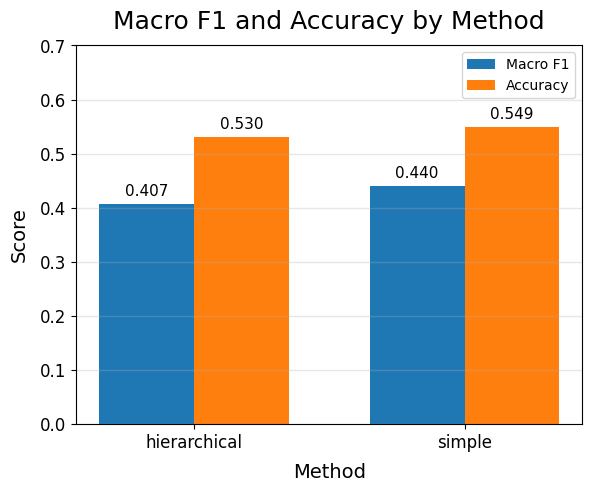

In [12]:
import numpy as np
import matplotlib.pyplot as plt

methods = grouped["method"].tolist()
macro_f1 = grouped["macro_f1"].to_numpy()
accuracy = grouped["accuracy"].to_numpy()

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))

bars_f1 = ax.bar(x - width/2, macro_f1, width, label="Macro F1")
bars_acc = ax.bar(x + width/2, accuracy, width, label="Accuracy")

ax.set_title("Macro F1 and Accuracy by Method", fontsize=18, pad=12)
ax.set_xlabel("Method", fontsize=14, labelpad=8)
ax.set_ylabel("Score", fontsize=14, labelpad=8)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.set_ylim(0, max(0.7, float(max(macro_f1.max(), accuracy.max())) + 0.05))
ax.grid(axis="y", linewidth=1, alpha=0.3)

# valor acima da barra
for bars in [bars_f1, bars_acc]:
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.01,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.legend()

plt.tight_layout(pad=1.0)
plt.show()


In [13]:
df

,model_name,output_method,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,confusion_matrix_json,...,wrong_format,emotion_refused,emotion_not_listed,total_time,total_time_hours,mean_time,response_time_std,response_time_mode,tie_counts_json,method
0,deepface,None,0.510464,0.327210,0.399528,0.345444,0.501869,0.549049,0.510464,"{""anger"":{""anger"":375,""disgust"":232,""fear"":44,...",...,0,0,0,322.92,0.089700,0.021052,0.012043,0.02,,None
1,llava:13b,discrete,0.475129,0.426525,0.542604,0.390312,0.526043,0.694171,0.475129,"{""anger"":{""anger"":315,""disgust"":43,""fear"":18,""...",...,2187,71,0,32011.67,8.892131,2.086946,0.505803,1.70,,simple
2,minicpm-v:8b,discrete,0.303084,0.297540,0.426439,0.263177,0.384475,0.606171,0.303084,"{""anger"":{""anger"":441,""disgust"":220,""fear"":61,...",...,3497,2943,0,15258.60,4.238500,0.994758,0.369856,0.80,,simple
3,llava:7b,discrete,0.531456,0.440516,0.551434,0.412749,0.564529,0.691856,0.531456,"{""anger"":{""anger"":319,""disgust"":58,""fear"":12,""...",...,1236,19,0,9820.74,2.727983,0.640246,0.161269,0.59,,simple
4,llava-phi3:3.8b,discrete,0.380142,0.316164,0.373686,0.282804,0.444100,0.550578,0.380142,"{""anger"":{""anger"":264,""disgust"":110,""fear"":29,...",...,3323,585,0,6702.26,1.861739,0.436942,0.148640,0.40,,simple
5,qwen3-vl:30b-a3b-instruct,discrete,0.756503,0.627703,0.642684,0.648975,0.756598,0.783284,0.756503,"{""anger"":{""anger"":665,""disgust"":206,""fear"":44,...",...,0,0,0,14540.64,4.039067,0.947952,0.163470,0.89,,simple
6,qwen3-vl:8b-instruct,discrete,0.758980,0.598045,0.619720,0.638043,0.752112,0.769304,0.758980,"{""anger"":{""anger"":730,""disgust"":308,""fear"":61,...",...,1,0,0,14509.93,4.030536,0.945950,0.156328,0.88,,simple
7,qwen3-vl:2b-thinking,discrete,0.623574,0.471903,0.521438,0.532330,0.617815,0.684547,0.623574,"{""anger"":{""anger"":677,""disgust"":348,""fear"":69,...",...,33,0,0,28246.84,7.846344,1.841505,1.539460,0.90,,simple
8,qwen3-vl:4b-instruct,discrete,0.722994,0.581013,0.588419,0.596567,0.721535,0.737512,0.722994,"{""anger"":{""anger"":713,""disgust"":263,""fear"":69,...",...,6,1,0,9687.12,2.690867,0.631535,0.977483,0.51,,simple
9,qwen3-vl:2b-instruct,discrete,0.652780,0.520233,0.569684,0.541817,0.653459,0.708081,0.652780,"{""anger"":{""anger"":615,""disgust"":109,""fear"":51,...",...,26,24,0,6311.89,1.753303,0.411493,0.587138,0.37,,simple


In [14]:
import pandas as pd

# -----------------------------
# 1. Colunas de F1 por classe
# -----------------------------
class_f1_cols = [
    "f1_anger",
    "f1_disgust",
    "f1_fear",
    "f1_happiness",
    "f1_neutral",
    "f1_sadness",
    "f1_surprise"
]

# -----------------------------
# 2. Filtragem justa (fair comparison)
#    Mantém apenas modelos que possuem
#    SIMPLE e HIERARCHICAL
# -----------------------------
required = {"simple", "hierarchical"}

models_ok = (
    df.groupby("model_name")["method"]
      .apply(lambda s: required.issubset(set(s)))
)

# df_fair = (
#     df[df["model_name"].isin(models_ok[models_ok].index)]
#       .query("method in @required")
#       .drop_duplicates(subset=["model_name", "method"])
#       .reset_index(drop=True)
# )

# -----------------------------
# 3. Converte para formato longo
#    (uma linha por classe)
# -----------------------------
df_long = df_fair.melt(
    id_vars=["model_name", "method"],
    value_vars=class_f1_cols,
    var_name="class",
    value_name="f1"
)

df_long["class"] = df_long["class"].str.replace("f1_", "")

# -----------------------------
# 4. Média OVERALL por classe e método
#    (entre todos os modelos e tamanhos)
# -----------------------------
df_class_overall = (
    df_long
    .groupby(["class", "method"])["f1"]
    .mean()
    .reset_index()
)

# -----------------------------
# 5. Pivot para comparação direta
# -----------------------------
df_class_pivot = (
    df_class_overall
    .pivot(index="class", columns="method", values="f1")
    .reset_index()
)

# -----------------------------
# 6. Método vencedor por classe
# -----------------------------
df_class_pivot["best_method"] = (
    df_class_pivot[["simple", "hierarchical"]]
    .idxmax(axis=1)
)

# -----------------------------
# 7. Resultado final
# -----------------------------
print(df_class_pivot)
print("\nNúmero de classes vencidas por método:")
print(df_class_pivot["best_method"].value_counts())


method      class  hierarchical    simple   best_method
0           anger      0.485544  0.490151        simple
1         disgust      0.171297  0.149797  hierarchical
2            fear      0.183751  0.134360  hierarchical
3       happiness      0.727995  0.737841        simple
4         neutral      0.535233  0.519260  hierarchical
5         sadness      0.508013  0.529682        simple
6        surprise      0.234436  0.519927        simple

Número de classes vencidas por método:
best_method
simple          4
hierarchical    3
Name: count, dtype: int64


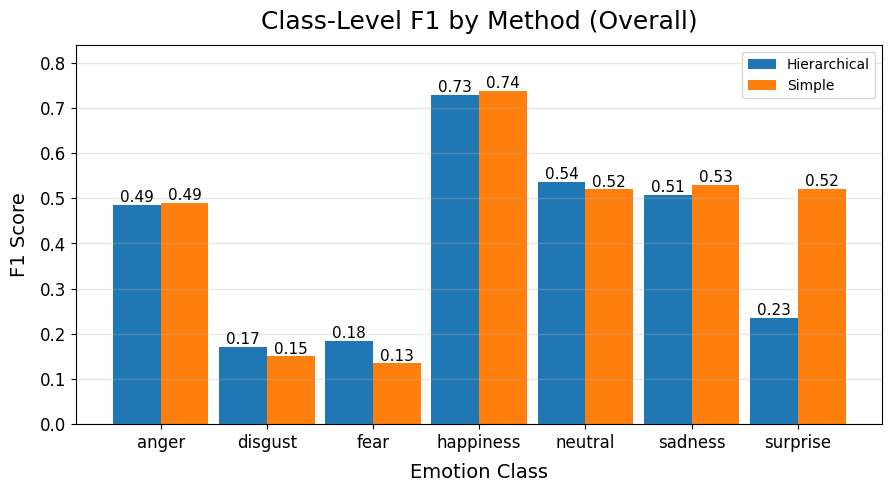

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados para o plot
# -----------------------------
classes = df_class_pivot["class"].tolist()
f1_simple = df_class_pivot["simple"].to_numpy()
f1_hier = df_class_pivot["hierarchical"].to_numpy()

x = np.arange(len(classes))
width = 0.45

# -----------------------------
# Figura
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5))

bars_hier = ax.bar(
    x - width/2,
    f1_hier,
    width,
    label="Hierarchical"
)

bars_simple = ax.bar(
    x + width/2,
    f1_simple,
    width,
    label="Simple"
)

# -----------------------------
# Estilo (igual ao anterior)
# -----------------------------
ax.set_title("Class-Level F1 by Method (Overall)", fontsize=18, pad=12)
ax.set_xlabel("Emotion Class", fontsize=14, labelpad=8)
ax.set_ylabel("F1 Score", fontsize=14, labelpad=8)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.set_ylim(0, max(0.7, float(max(f1_simple.max(), f1_hier.max())) + 0.1))
ax.grid(axis="y", linewidth=1, alpha=0.3)

# -----------------------------
# Valores acima das barras
# -----------------------------
for bars in [bars_hier, bars_simple]:
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.legend()
plt.tight_layout(pad=1.0)
plt.show()


In [25]:
# F1 médio por classe (já discutido)
df_class_pivot["mean_f1"] = (
    df_class_pivot[["simple", "hierarchical"]]
    .mean(axis=1)
)

# Ranking de dificuldade
df_difficulty = (
    df_class_pivot
    .sort_values("mean_f1", ascending=True)  # menor F1 = mais difícil
    .reset_index(drop=True)
)

# adiciona posição no ranking
df_difficulty["difficulty_rank"] = df_difficulty.index + 1

df_difficulty[
    ["difficulty_rank", "class", "mean_f1", "delta_f1"]
]


method,difficulty_rank,class,mean_f1,delta_f1
0,1,fear,0.159056,0.049391
1,2,disgust,0.160547,0.021500
2,3,surprise,0.377181,-0.285491
3,4,anger,0.487848,-0.004607
4,5,sadness,0.518847,-0.021669
5,6,neutral,0.527247,0.015973
6,7,happiness,0.732918,-0.009846


In [26]:
# 1) Mean F1 (média entre métodos)
df_class_pivot["mean_f1"] = df_class_pivot[["simple", "hierarchical"]].mean(axis=1)

# 2) Ordena: mais difícil em cima (menor mean_f1)
df_sorted = (
    df_class_pivot
    .sort_values("mean_f1", ascending=True)
    .reset_index(drop=True)
)

# 3) Função para formatar linha LaTeX
def fmt_row(row):
    s = row["simple"]
    h = row["hierarchical"]
    m = row["mean_f1"]
    d = row["delta_f1"]

    if s >= h:
        s_fmt = f"\\textbf{{{s:.3f}}}"
        h_fmt = f"{h:.3f}"
    else:
        s_fmt = f"{s:.3f}"
        h_fmt = f"\\textbf{{{h:.3f}}}"

    m_fmt = f"{m:.3f}"
    d_fmt = f"\\underline{{{d:+.3f}}}"

    return f'{row["class"]} & {s_fmt} & {h_fmt} & {m_fmt} & {d_fmt} \\\\'

# 4) Print das linhas (já na ordem "mais difícil -> mais fácil")
for _, r in df_sorted.iterrows():
    print(fmt_row(r))


fear & 0.134 & \textbf{0.184} & 0.159 & \underline{+0.049} \\
disgust & 0.150 & \textbf{0.171} & 0.161 & \underline{+0.021} \\
surprise & \textbf{0.520} & 0.234 & 0.377 & \underline{-0.285} \\
anger & \textbf{0.490} & 0.486 & 0.488 & \underline{-0.005} \\
sadness & \textbf{0.530} & 0.508 & 0.519 & \underline{-0.022} \\
neutral & 0.519 & \textbf{0.535} & 0.527 & \underline{+0.016} \\
happiness & \textbf{0.738} & 0.728 & 0.733 & \underline{-0.010} \\


method      class  hierarchical    simple  delta_f1
0            fear      0.183751  0.134360  0.049391
1         disgust      0.171297  0.149797  0.021500
2         neutral      0.535233  0.519260  0.015973
3           anger      0.485544  0.490151 -0.004607
4       happiness      0.727995  0.737841 -0.009846
5         sadness      0.508013  0.529682 -0.021669
6        surprise      0.234436  0.519927 -0.285491


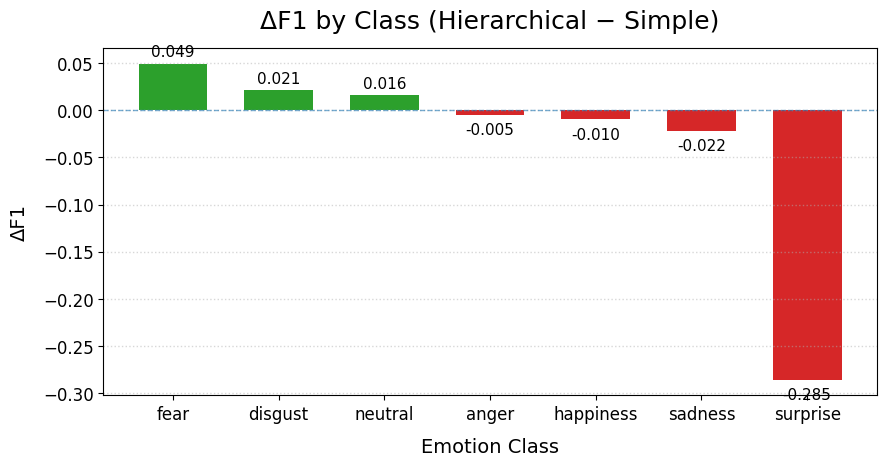

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Pré-requisito: df_class_pivot já existe e tem colunas:
# ["class", "simple", "hierarchical", ...]
# ------------------------------------------------------------

# -----------------------------
# 1) ΔF1 por classe (hier - simple)
# -----------------------------
df_class_pivot["delta_f1"] = df_class_pivot["hierarchical"] - df_class_pivot["simple"]

# Tabela ordenada (maior ganho -> maior perda)
df_delta = (
    df_class_pivot[["class", "hierarchical", "simple", "delta_f1"]]
    .sort_values("delta_f1", ascending=False)
    .reset_index(drop=True)
)

print(df_delta)
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Assume df_delta já ordenado por delta_f1 (desc)
# ------------------------------------------------------------
classes = df_delta["class"].tolist()
delta = df_delta["delta_f1"].to_numpy()

x = np.arange(len(classes))

# cores semânticas
colors = ["#2ca02c" if d > 0 else "#d62728" for d in delta]

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.bar(
    x,
    delta,
    color=colors,
    width=0.65
)

# -----------------------------
# Estilo
# -----------------------------
ax.set_title("ΔF1 by Class (Hierarchical − Simple)", fontsize=18, pad=14)
ax.set_xlabel("Emotion Class", fontsize=14, labelpad=10)
ax.set_ylabel("ΔF1", fontsize=14, labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# linha zero (referência)
ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)

# grid suave
ax.grid(axis="y", linestyle=":", linewidth=1, alpha=0.5)

# -----------------------------
# Valores nas barras
# -----------------------------
for b, d in zip(bars, delta):
    ax.text(
        b.get_x() + b.get_width()/2,
        d + (0.004 if d >= 0 else -0.008),
        f"{d:.3f}",
        ha="center",
        va="bottom" if d >= 0 else "top",
        fontsize=11
    )

plt.tight_layout(pad=1.2)
plt.show()


In [22]:
def fmt_row(row):
    s = row["simple"]
    h = row["hierarchical"]
    d = row["delta_f1"]

    if s >= h:
        s_fmt = f"\\textbf{{{s:.3f}}}"
        h_fmt = f"{h:.3f}"
    else:
        s_fmt = f"{s:.3f}"
        h_fmt = f"\\textbf{{{h:.3f}}}"

    d_fmt = f"\\underline{{{d:+.3f}}}"

    return f'{row["class"]} & {s_fmt} & {h_fmt} & {d_fmt} \\\\'

for _, r in df_class_pivot.sort_index().iterrows():
    print(fmt_row(r))


anger & \textbf{0.490} & 0.486 & \underline{-0.005} \\
disgust & 0.150 & \textbf{0.171} & \underline{+0.021} \\
fear & 0.134 & \textbf{0.184} & \underline{+0.049} \\
happiness & \textbf{0.738} & 0.728 & \underline{-0.010} \\
neutral & 0.519 & \textbf{0.535} & \underline{+0.016} \\
sadness & \textbf{0.530} & 0.508 & \underline{-0.022} \\
surprise & \textbf{0.520} & 0.234 & \underline{-0.285} \\


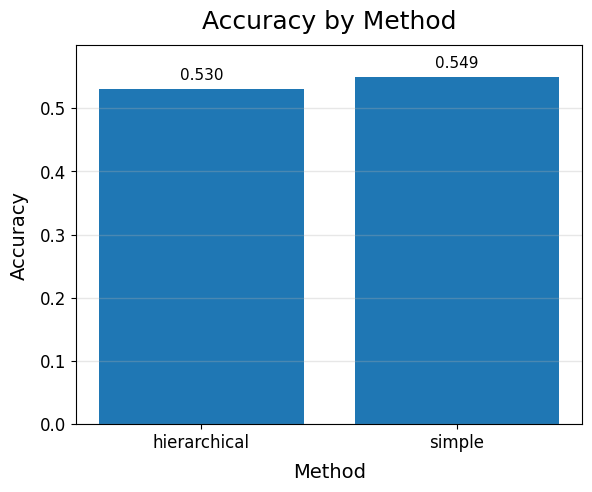

In [65]:
import numpy as np
import matplotlib.pyplot as plt

methods = grouped["method"].tolist()
accuracy = grouped["accuracy"].to_numpy()

x = np.arange(len(methods))

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(x, accuracy, label="Accuracy")

ax.set_title("Accuracy by Method", fontsize=18, pad=12)
ax.set_xlabel("Method", fontsize=14, labelpad=8)
ax.set_ylabel("Accuracy", fontsize=14, labelpad=8)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.set_ylim(0, float(accuracy.max()) + 0.05)
ax.grid(axis="y", linewidth=1, alpha=0.3)

# valor acima da barra
for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        h + 0.01,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout(pad=1.0)
plt.show()

## General by family:

In [66]:
df_fair["family"] = (
    df_fair["model_name"]
      .astype(str)
      .str.strip()
      .str.split(":", n=1)
      .str[0]
)


In [67]:
df_fair["family"].value_counts()

family
qwen3-vl        6
llava           4
gemma3          4
llava-phi3      2
llava-llama3    2
Name: count, dtype: int64

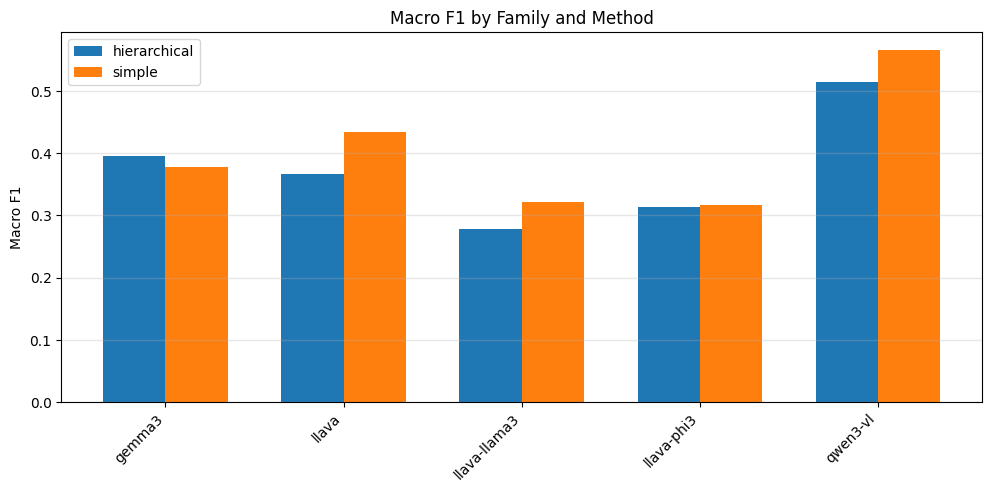

In [68]:
import numpy as np
import matplotlib.pyplot as plt

grouped_family = (
    df_fair.groupby(["family", "method"], as_index=False)
      .agg(macro_f1=("macro_f1", "mean"))
)

pivot = grouped_family.pivot(index="family", columns="method", values="macro_f1").fillna(0)
families = pivot.index.tolist()
methods = pivot.columns.tolist()

x = np.arange(len(families))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, m in enumerate(methods):
    ax.bar(x + (i - (len(methods)-1)/2)*width, pivot[m].to_numpy(), width, label=m)

ax.set_xticks(x)
ax.set_xticklabels(families, rotation=45, ha="right")
ax.set_ylabel("Macro F1")
ax.set_title("Macro F1 by Family and Method")
ax.grid(axis="y", linewidth=1, alpha=0.3)
ax.legend()

plt.tight_layout(pad=1.0)
plt.show()


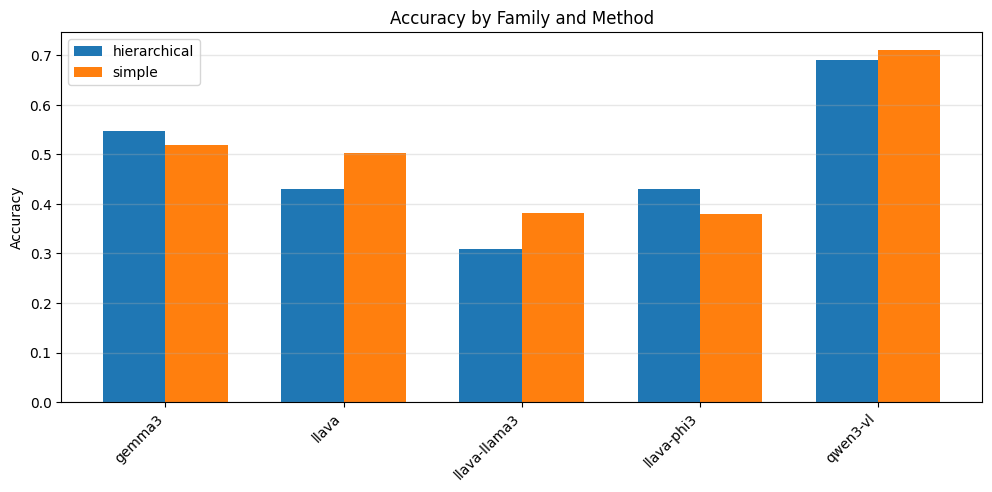

In [69]:
import numpy as np
import matplotlib.pyplot as plt

grouped_family = (
    df_fair.groupby(["family", "method"], as_index=False)
      .agg(accuracy=("accuracy", "mean"))
)

pivot = grouped_family.pivot(index="family", columns="method", values="accuracy").fillna(0)
families = pivot.index.tolist()
methods = pivot.columns.tolist()

x = np.arange(len(families))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, m in enumerate(methods):
    ax.bar(x + (i - (len(methods)-1)/2)*width, pivot[m].to_numpy(), width, label=m)

ax.set_xticks(x)
ax.set_xticklabels(families, rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Family and Method")
ax.grid(axis="y", linewidth=1, alpha=0.3)
ax.legend()

plt.tight_layout(pad=1.0)
plt.show()


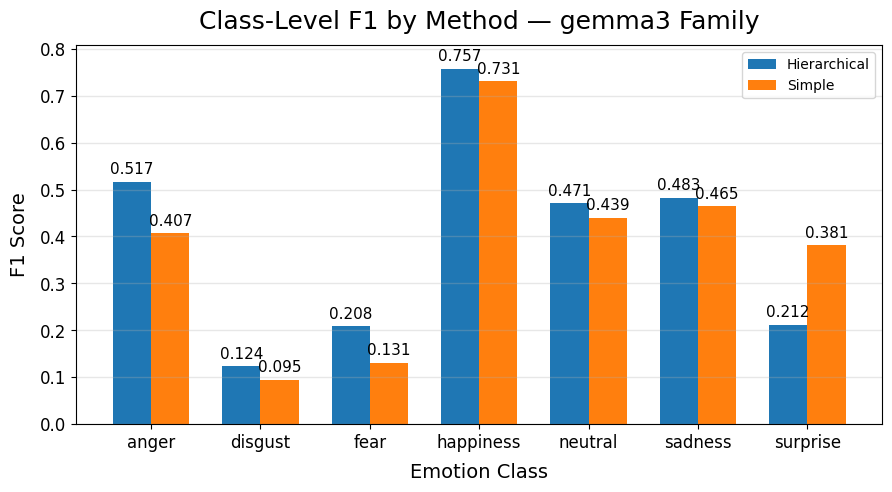

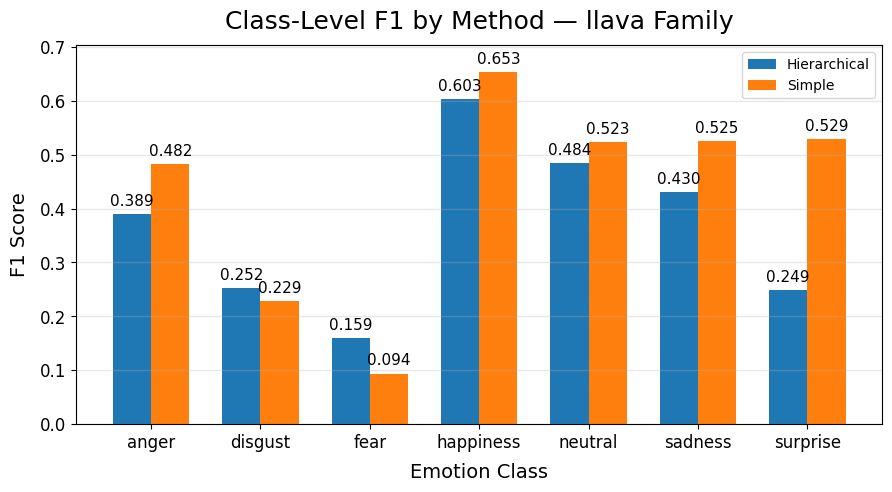

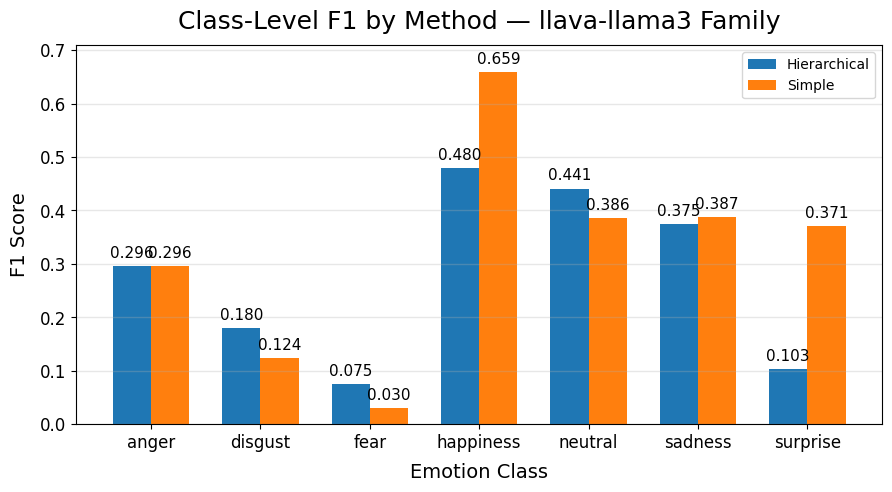

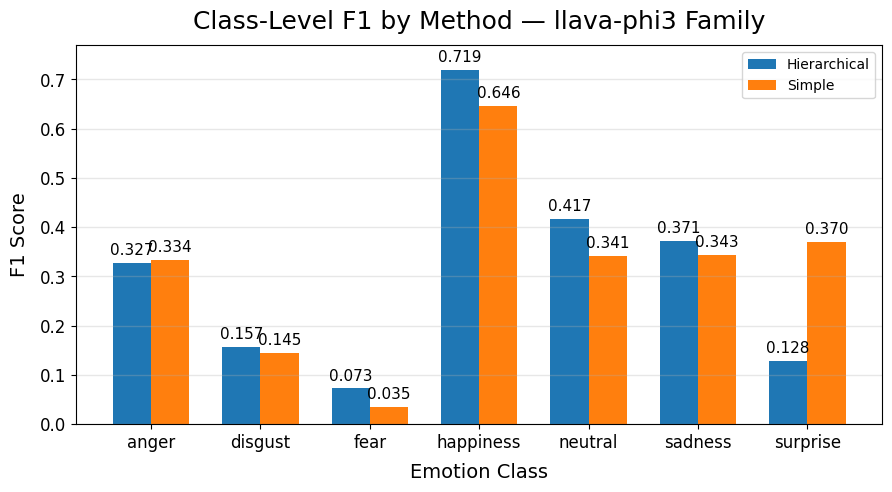

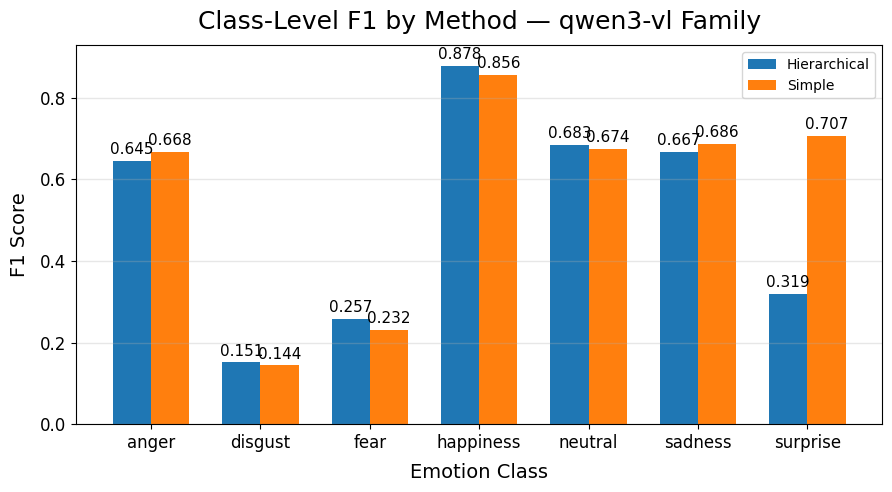

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_long["family"] = (
    df_long["model_name"]
      .astype(str)
      .str.strip()
      .str.split(":", n=1)
      .str[0]
)


# -----------------------------
# -----------------------------
for family, df_family in df_long.groupby("family"):

    # Média OVERALL por classe e método dentro da família
    df_family_overall = (
        df_family
        .groupby(["class", "method"])["f1"]
        .mean()
        .reset_index()
    )

    # Pivot para o formato do gráfico
    df_family_pivot = (
        df_family_overall
        .pivot(index="class", columns="method", values="f1")
        .reset_index()
    )

    # Garante ordem consistente das classes
    classes = df_family_pivot["class"].tolist()
    f1_simple = df_family_pivot["simple"].to_numpy()
    f1_hier = df_family_pivot["hierarchical"].to_numpy()

    x = np.arange(len(classes))
    width = 0.35

    # -----------------------------
    # -----------------------------
    fig, ax = plt.subplots(figsize=(9, 5))

    bars_hier = ax.bar(
        x - width/2,
        f1_hier,
        width,
        label="Hierarchical"
    )

    bars_simple = ax.bar(
        x + width/2,
        f1_simple,
        width,
        label="Simple"
    )

    # -----------------------------
    # -----------------------------
    ax.set_title(
        f"Class-Level F1 by Method — {family} Family",
        fontsize=18,
        pad=12
    )
    ax.set_xlabel("Emotion Class", fontsize=14, labelpad=8)
    ax.set_ylabel("F1 Score", fontsize=14, labelpad=8)

    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=12)
    ax.tick_params(axis="y", labelsize=12)

    ax.set_ylim(
        0,
        max(0.7, float(max(f1_simple.max(), f1_hier.max())) + 0.05)
    )
    ax.grid(axis="y", linewidth=1, alpha=0.3)

    # -----------------------------
    # -----------------------------
    for bars in [bars_hier, bars_simple]:
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + 0.01,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=11
            )

    ax.legend()
    plt.tight_layout(pad=1.0)
    plt.show()


C:\Users\FernandaBufon\AppData\Local\Temp\ipykernel_5156\2130432700.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(delta.index, rotation=45, ha="right")


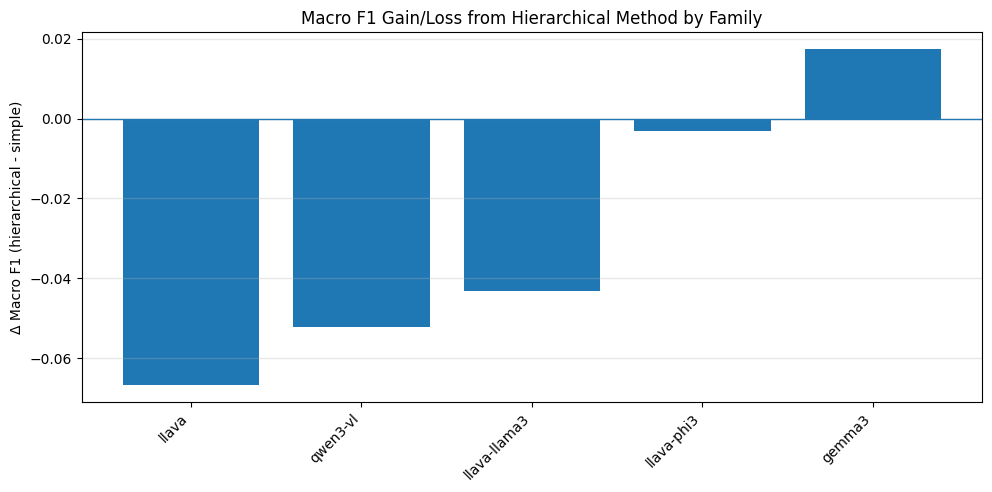

In [19]:
import matplotlib.pyplot as plt

grouped_family = (
    df_fair.groupby(["family", "method"], as_index=False)
      .agg(macro_f1=("macro_f1", "mean"))
)

pivot = grouped_family.pivot(index="family", columns="method", values="macro_f1")
delta = (pivot["hierarchical"] - pivot["simple"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(delta.index, delta.to_numpy())
ax.axhline(0, linewidth=1)

ax.set_xticklabels(delta.index, rotation=45, ha="right")
ax.set_ylabel("Δ Macro F1 (hierarchical - simple)")
ax.set_title("Macro F1 Gain/Loss from Hierarchical Method by Family")
ax.grid(axis="y", linewidth=1, alpha=0.3)

plt.tight_layout(pad=1.0)
plt.show()


## Specific for each family

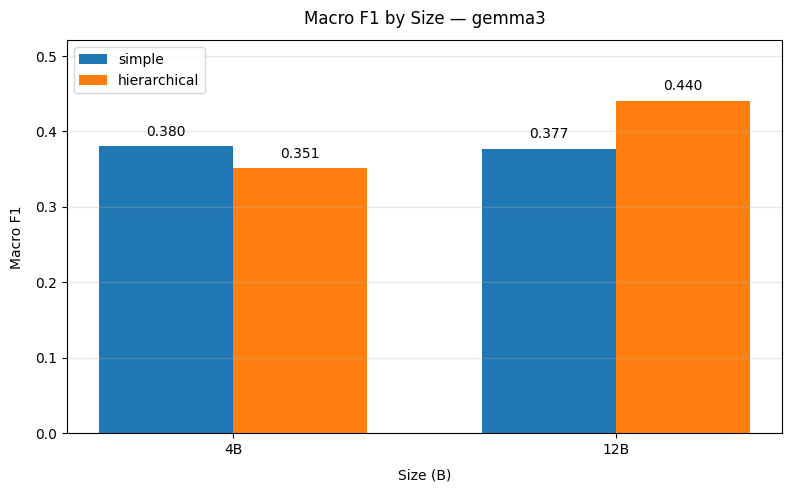

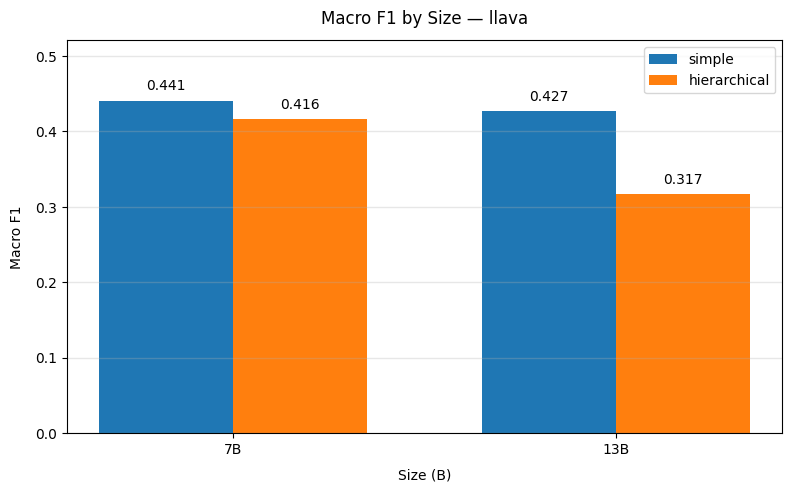

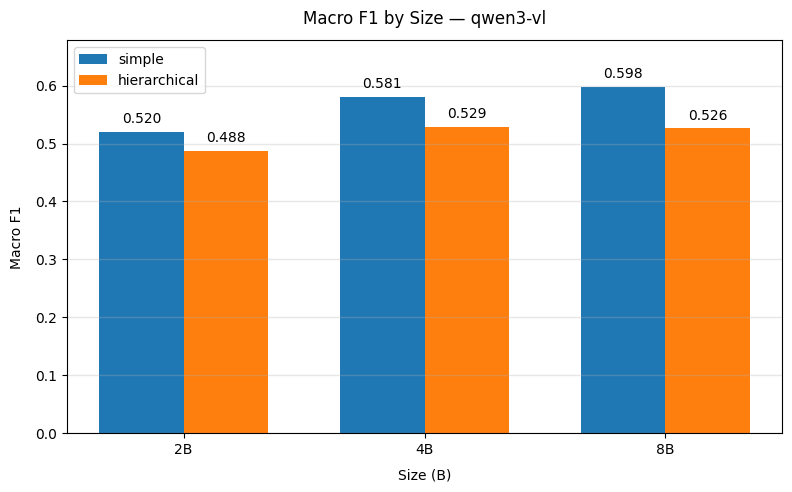

In [23]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df_fair.copy()

# base do modelo (antes do ":")
df["base_model"] = df["model_name"].astype(str).str.strip().str.split(":", n=1).str[0]

# extrair tamanho em B (logo após o ":" -> "2b", "3.8b", "8b"...)
after_colon = df["model_name"].astype(str).str.strip().str.split(":", n=1).str[1].fillna("")
df["size_b"] = pd.to_numeric(after_colon.str.extract(r"^(\d+(?:\.\d+)?)b", expand=False), errors="coerce")

# mantém só métodos de interesse e linhas com size
df = df[df["method"].isin(["simple", "hierarchical"])].copy()
df = df[df["size_b"].notna()].copy()

# agrega
grouped = (
    df.groupby(["base_model", "size_b", "method"], as_index=False)
      .agg(macro_f1=("macro_f1", "mean"))
)

# escolhe apenas base_models com pelo menos 2 tamanhos distintos
valid_bases = (
    grouped.groupby("base_model")["size_b"].nunique()
           .loc[lambda s: s >= 2]
           .index
)

for base in sorted(valid_bases):
    sub = grouped[grouped["base_model"] == base].sort_values("size_b")

    pivot = sub.pivot(index="size_b", columns="method", values="macro_f1")

    # garante as duas colunas (caso algum tamanho não tenha um método)
    for col in ["simple", "hierarchical"]:
        if col not in pivot.columns:
            pivot[col] = np.nan
    pivot = pivot[["simple", "hierarchical"]]

    sizes = pivot.index.to_numpy()
    x = np.arange(len(sizes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars_simple = ax.bar(x - width/2, pivot["simple"].to_numpy(), width, label="simple")
    bars_hier   = ax.bar(x + width/2, pivot["hierarchical"].to_numpy(), width, label="hierarchical")

    ax.set_title(f"Macro F1 by Size — {base}", pad=12)
    ax.set_xlabel("Size (B)", labelpad=8)
    ax.set_ylabel("Macro F1", labelpad=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{s:g}B" for s in sizes])
    ax.grid(axis="y", linewidth=1, alpha=0.3)
    ax.legend()

    ymax = np.nanmax(pivot[["simple", "hierarchical"]].to_numpy())
    ax.set_ylim(0, ymax + 0.08)  # ajuste 0.08 conforme você quiser


    # valores acima das barras (ignora NaN)
    for bars in [bars_simple, bars_hier]:
        for b in bars:
            h = b.get_height()
            if np.isfinite(h):
                ax.text(
                    b.get_x() + b.get_width()/2,
                    h + 0.01,
                    f"{h:.3f}",
                    ha="center",
                    va="bottom"
                )

    plt.tight_layout(pad=1.0)
    plt.show()


In [21]:
import pandas as pd
import numpy as np

df = df_fair.copy()

# model family = tudo antes do ":"
df["model_family"] = (
    df["model_name"].astype(str).str.strip().str.split(":", n=1).str[0]
)

# model size = número antes do 'b' logo após ":"
after_colon = df["model_name"].astype(str).str.strip().str.split(":", n=1).str[1].fillna("")
df["model_size"] = pd.to_numeric(
    after_colon.str.extract(r"^(\d+(?:\.\d+)?)b", expand=False),
    errors="coerce"
)

df = df[df["method"].isin(["simple", "hierarchical"])].copy()
df = df[df["model_size"].notna()].copy()

grouped = (
    df.groupby(["model_family", "model_size", "method"], as_index=False)
      .agg(macro_f1=("macro_f1", "mean"))
)

tab = (
    grouped.pivot(index=["model_family", "model_size"], columns="method", values="macro_f1")
          .reset_index()
          .rename(columns={"hierarchical": "f1_hierarchical", "simple": "f1_simple"})
)

# ΔF1 (hier - simple)
tab["delta_f1"] = tab["f1_hierarchical"] - tab["f1_simple"]

tab = tab.sort_values(["model_family", "model_size"], ascending=[True, True]).reset_index(drop=True)

def fmt(x):
    return "-" if pd.isna(x) else f"{x:.3f}"

def fmt_delta(x):
    return "-" if pd.isna(x) else f"{x:+.3f}"

def bold_best(h, s):
    h_str, s_str = fmt(h), fmt(s)
    if pd.notna(h) and pd.notna(s):
        if h > s:
            h_str = r"\textbf{" + h_str + "}"
        elif s > h:
            s_str = r"\textbf{" + s_str + "}"
        else:
            h_str = r"\textbf{" + h_str + "}"
            s_str = r"\textbf{" + s_str + "}"
    return h_str, s_str

rows = []
for _, r in tab.iterrows():
    h_str, s_str = bold_best(r["f1_hierarchical"], r["f1_simple"])
    rows.append({
        "model_family": r["model_family"],
        "model_size": f"{r['model_size']:g}B",
        "f1_hierarchical": h_str,
        "f1_simple": s_str,
        "delta_f1": fmt_delta(r["delta_f1"]),
    })

tab_fmt = pd.DataFrame(rows)

latex = tab_fmt.to_latex(
    index=False,
    escape=False,                 # necessário p/ \textbf
    column_format="llrrr"         # family, size, f1h, f1s, delta
)

print(latex)


\begin{tabular}{llrrr}
\toprule
model_family & model_size & f1_hierarchical & f1_simple & delta_f1 \\
\midrule
gemma3 & 4B & 0.351 & \textbf{0.380} & -0.029 \\
gemma3 & 12B & \textbf{0.440} & 0.377 & +0.064 \\
llava & 7B & 0.416 & \textbf{0.441} & -0.024 \\
llava & 13B & 0.317 & \textbf{0.427} & -0.109 \\
llava-llama3 & 8B & 0.279 & \textbf{0.322} & -0.043 \\
llava-phi3 & 3.8B & 0.313 & \textbf{0.316} & -0.003 \\
qwen3-vl & 2B & 0.488 & \textbf{0.520} & -0.033 \\
qwen3-vl & 4B & 0.529 & \textbf{0.581} & -0.052 \\
qwen3-vl & 8B & 0.526 & \textbf{0.598} & -0.072 \\
\bottomrule
\end{tabular}



In [24]:
import pandas as pd
import numpy as np

df = df_fair.copy()

df["model_family"] = (
    df["model_name"].astype(str).str.strip().str.split(":", n=1).str[0]
)

after_colon = df["model_name"].astype(str).str.strip().str.split(":", n=1).str[1].fillna("")
df["model_size"] = pd.to_numeric(
    after_colon.str.extract(r"^(\d+(?:\.\d+)?)b", expand=False),
    errors="coerce"
)

df = df[df["method"].isin(["simple", "hierarchical"])].copy()
df = df[df["model_size"].notna()].copy()

grouped = (
    df.groupby(["model_family", "model_size", "method"], as_index=False)
      .agg(macro_f1=("macro_f1", "mean"))
)

tab = (
    grouped.pivot(index=["model_family", "model_size"], columns="method", values="macro_f1")
          .reset_index()
          .rename(columns={"hierarchical": "f1_hierarchical", "simple": "f1_simple"})
)

tab["delta_f1"] = tab["f1_hierarchical"] - tab["f1_simple"]
tab = tab.sort_values(["model_family", "model_size"]).reset_index(drop=True)

# média do delta por família
fam_mean = (
    tab.groupby("model_family", as_index=False)["delta_f1"]
       .mean()
       .rename(columns={"delta_f1": "delta_f1_mean"})
)

def fmt(x):
    return "-" if pd.isna(x) else f"{x:.3f}"

def fmt_delta(x):
    return "-" if pd.isna(x) else f"{x:+.3f}"

def bold_best(h, s):
    h_str, s_str = fmt(h), fmt(s)
    if pd.notna(h) and pd.notna(s):
        if h > s:
            h_str = r"\textbf{" + h_str + "}"
        elif s > h:
            s_str = r"\textbf{" + s_str + "}"
        else:
            h_str = r"\textbf{" + h_str + "}"
            s_str = r"\textbf{" + s_str + "}"
    return h_str, s_str

# monta linhas com "Average ΔF1" por família
rows = []
for fam, sub in tab.groupby("model_family", sort=True):
    for _, r in sub.iterrows():
        h_str, s_str = bold_best(r["f1_hierarchical"], r["f1_simple"])
        rows.append({
            "model_family": fam,
            "model_size": f"{r['model_size']:g}B",
            "f1_hierarchical": h_str,
            "f1_simple": s_str,
            "delta_f1": fmt_delta(r["delta_f1"]),
        })

    mean_val = fam_mean.loc[fam_mean["model_family"] == fam, "delta_f1_mean"].iloc[0]
    rows.append({
        "model_family": fam,
        "model_size": r"\textit{Average}",
        "f1_hierarchical": "-",
        "f1_simple": "-",
        "delta_f1": r"\textbf{" + fmt_delta(mean_val) + "}",
    })

tab_fmt = pd.DataFrame(rows)

latex = tab_fmt.to_latex(
    index=False,
    escape=False,
    column_format="llrrr"
)

print(latex)


\begin{tabular}{llrrr}
\toprule
model_family & model_size & f1_hierarchical & f1_simple & delta_f1 \\
\midrule
gemma3 & 4B & 0.351 & \textbf{0.380} & -0.029 \\
gemma3 & 12B & \textbf{0.440} & 0.377 & +0.064 \\
gemma3 & \textit{Average} & - & - & \textbf{+0.017} \\
llava & 7B & 0.416 & \textbf{0.441} & -0.024 \\
llava & 13B & 0.317 & \textbf{0.427} & -0.109 \\
llava & \textit{Average} & - & - & \textbf{-0.067} \\
llava-llama3 & 8B & 0.279 & \textbf{0.322} & -0.043 \\
llava-llama3 & \textit{Average} & - & - & \textbf{-0.043} \\
llava-phi3 & 3.8B & 0.313 & \textbf{0.316} & -0.003 \\
llava-phi3 & \textit{Average} & - & - & \textbf{-0.003} \\
qwen3-vl & 2B & 0.488 & \textbf{0.520} & -0.033 \\
qwen3-vl & 4B & 0.529 & \textbf{0.581} & -0.052 \\
qwen3-vl & 8B & 0.526 & \textbf{0.598} & -0.072 \\
qwen3-vl & \textit{Average} & - & - & \textbf{-0.052} \\
\bottomrule
\end{tabular}

